```{toctree}
:maxdepth: 3
:caption: Contents:

# Walkthrough Example

General workflow of oceanicospy library for new users

## Importing libraries

In [1]:
#import general libraries used on several sections
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import glob
from pathlib import Path

## Observations

In [2]:
#import libraries used for observation reading
from oceanicospy.observations import pressure_sensors,weather_stations,AWAC,\
                                    WaveBuoy,ctd,HOBO_Temp,HOBO_TempCond

### Pressure sensors: AQuaLogger and RBR

Process two pressure sensor observation from San Andrés Island from 2025, an AQuaLogger and an RBR

In [8]:
measurement_pressure_sensors_paths = ['../data/oceanicospy-example/observations/AQ/',
                                      '../data/oceanicospy-example/observations/RBR/SV28-1_0525/']

sampling_AQ = dict(anchoring_depth=9.5, sensor_height=0.2, sampling_freq=1,burst_length_s=2048,
                    start_time=datetime(2025,5,12,0,0,0),
                    end_time=datetime(2025,5,17,23,0,0))
sampling_RBR = dict(anchoring_depth=8, sensor_height=0.2, sampling_freq=1, burst_length_s=3600,
                    start_time=datetime(2025,5,22,0,0,0),
                    end_time=datetime(2025,5,27,23,0,0))

In [9]:
sampling_data = [sampling_AQ,sampling_RBR]
metadata_list=['AQ','RBR']
dict_raw_measurements = dict()
dict_clean_measurements = dict() 

for idx,measurement_path in enumerate(measurement_pressure_sensors_paths):
    print(measurement_path)
    if 'AQ' in measurement_path:
        object_device = pressure_sensors.AQUAlogger(measurement_path, sampling_data[idx],
                                                    filename='SV27_0525.csv')
    elif 'Bluelog' in measurement_path:
        object_device = pressure_sensors.Bluelog(measurement_path, sampling_data[idx])
    else:
        object_device = pressure_sensors.RBR(measurement_path,sampling_data[idx])
    raw_data = object_device.get_raw_records()
    clean_data = object_device.get_clean_records()
    dict_raw_measurements[metadata_list[idx]] = raw_data
    dict_clean_measurements[metadata_list[idx]] = clean_data

../data/oceanicospy-example/observations/AQ/
../data/oceanicospy-example/observations/RBR/SV28-1_0525/


In [16]:
dict_clean_measurements['AQ'].head()

,pressure[bar],depth[m],depth_aux[m],burstId,eta[m]
date,,,,,
2025-05-12 01:00:00,1.853331,9.701095,8.337958,1,0.000985
2025-05-12 01:00:01,1.852619,9.693552,8.330892,1,-0.006553
2025-05-12 01:00:02,1.852762,9.695061,8.332311,1,-0.005039
2025-05-12 01:00:03,1.852477,9.692044,8.329482,1,-0.008051
2025-05-12 01:00:04,1.851907,9.686010,8.323825,1,-0.014079


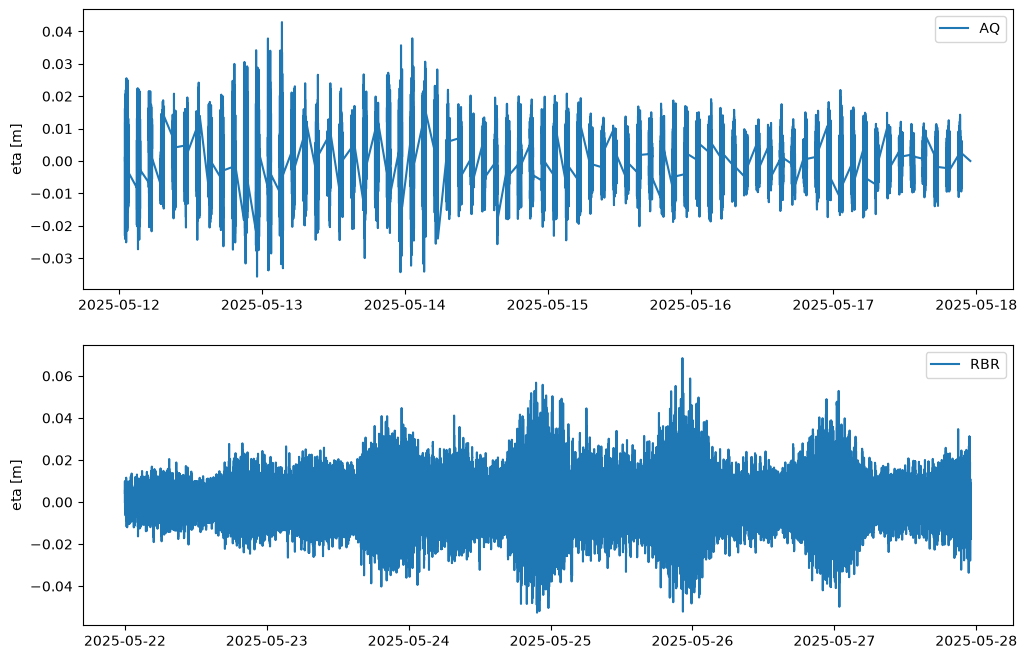

In [19]:
fig, ax = plt.subplots(2,1,figsize=(12,8),sharex=False)
for idx,metadata in enumerate(metadata_list):
    ax[idx].plot(dict_clean_measurements[metadata].index,dict_clean_measurements[metadata]['eta[m]'],label=metadata)
    ax[idx].set_ylabel('eta [m]')
    ax[idx].legend()

## Analysis

Now, previois processed observations will be analyzed for wave params estimation by temporal and spectral methods

### Import libraries

In [23]:
from oceanicospy.analysis import temporal
from oceanicospy.analysis import spectral
from oceanicospy.plots import *

### Temporal wave parameters estimation

In [21]:
wave_params_dfs = dict()
for idx,metadata in enumerate(metadata_list):
    TemporalAnalyzer = temporal.WaveTemporalAnalyzer(dict_clean_measurements[metadata],
                                                     sampling_data[idx])
    print(f"The {metadata} sensor data is being analyzed using {type(TemporalAnalyzer)}")
    wave_params_dfs[metadata_list[idx]] = TemporalAnalyzer.compute_params_from_zero_upcrossing()

The AQ sensor data is being analyzed using <class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
The following bursts have been removed due to incorrect length: [72]
The RBR sensor data is being analyzed using <class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
The following bursts have been removed due to incorrect length: [144]


In [22]:
#Quick check on dataframes
wave_params_dfs['AQ'].head()

,H1/3,Tmean
time,,
2025-05-12 01:00:00,0.137625,13.127994
2025-05-12 03:00:00,0.149663,12.474390
2025-05-12 05:00:00,0.109776,12.132015
2025-05-12 07:00:00,0.124505,10.327230
2025-05-12 09:00:00,0.124143,13.018086


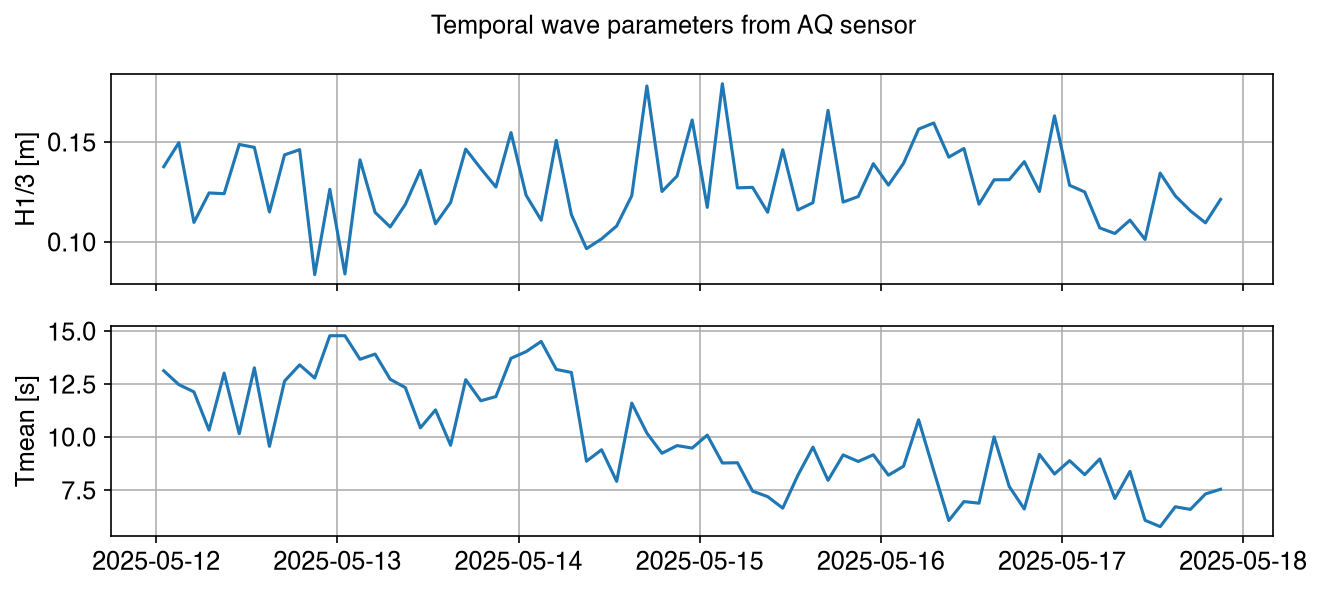

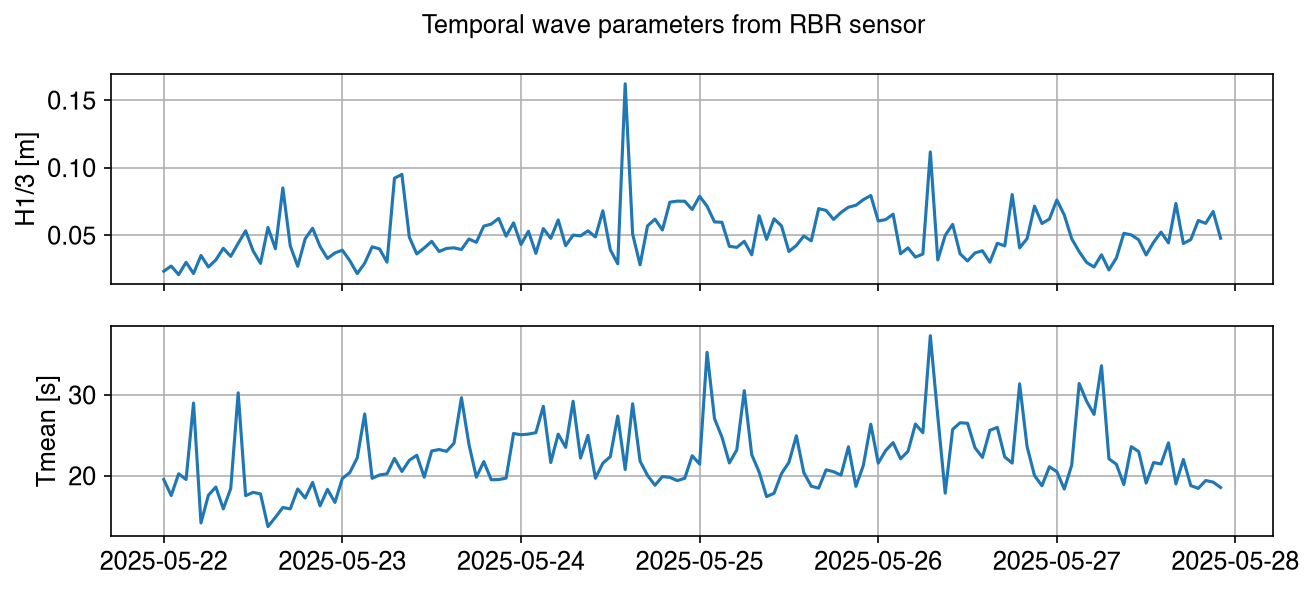

In [30]:
for idx,metadata in enumerate(metadata_list):
    fig, ax = plt.subplots(2,1,figsize=(10,4),sharex=True)
    ax[0].plot(wave_params_dfs[metadata].index,wave_params_dfs[metadata]['H1/3'],label=metadata)
    ax[0].set_ylabel('H1/3 [m]')
    ax[0].grid()

    ax[1].plot(wave_params_dfs[metadata].index,wave_params_dfs[metadata]['Tmean'],label=metadata)
    ax[1].set_ylabel('Tmean [s]')
    ax[1].grid()

    fig.suptitle(f"Temporal wave parameters from {metadata} sensor")
    plt.show()

### Spectral wave parameters estimation

In [24]:
dict_spectra_welch = dict()
dict_integral_params_welch = dict()
dict_spectra_fft = dict()
dict_integral_params_fft = dict()

for idx,metadata in enumerate(metadata_list):
    SpectralAnalyzer = spectral.WaveSpectralAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(SpectralAnalyzer))

    spectra_welch,params_welch = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='welch',
                                                                                    kp_correction=False,
                                                                                    ig_split=True,
                                                                                    freq_split=0.04, 
                                                                                    window_type='hamming',
                                                                                    window_length=1024,
                                                                                    overlap=512,
                                                                                    smoothing_bins=6)
    spectra_fft,params_fft = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='fft',
                                                                                kp_correction=False,
                                                                                ig_split=True,
                                                                                freq_split=0.04)

    dict_spectra_welch[metadata_list[idx]] = spectra_welch
    dict_integral_params_welch[metadata_list[idx]] = params_welch
    dict_spectra_fft[metadata_list[idx]] = spectra_fft
    dict_integral_params_fft[metadata_list[idx]] = params_fft

<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>
<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>


In [31]:
dict_integral_params_welch['AQ'].head()

,Hm0,Hrms,Hmean,Tp,Tm01,Tm02,time,Hm0_ig,Hm0_sw
date,,,,,,,,,
2025-05-12 01:00:00,0.036068,0.025479,0.022580,204.800000,26.855341,13.001155,2025-05-12 01:00:00,0.031699,0.015324
2025-05-12 03:00:00,0.033713,0.023815,0.021105,256.000000,27.786927,12.277584,2025-05-12 03:00:00,0.030180,0.012957
2025-05-12 05:00:00,0.025474,0.017995,0.015947,256.000000,24.934993,10.655178,2025-05-12 05:00:00,0.022562,0.009868
2025-05-12 07:00:00,0.022511,0.015901,0.014092,256.000000,22.428117,9.615137,2025-05-12 07:00:00,0.020155,0.007773
2025-05-12 09:00:00,0.026564,0.018765,0.016630,341.333333,30.557403,11.458326,2025-05-12 09:00:00,0.024427,0.008229


In [41]:
dict_spectra_welch['AQ'].keys()

dict_keys(['S', 'dir', 'freq', 'time'])

Text(0.5, 0.98, 'Comparison of Welch and FFT methods for AQ sensor')

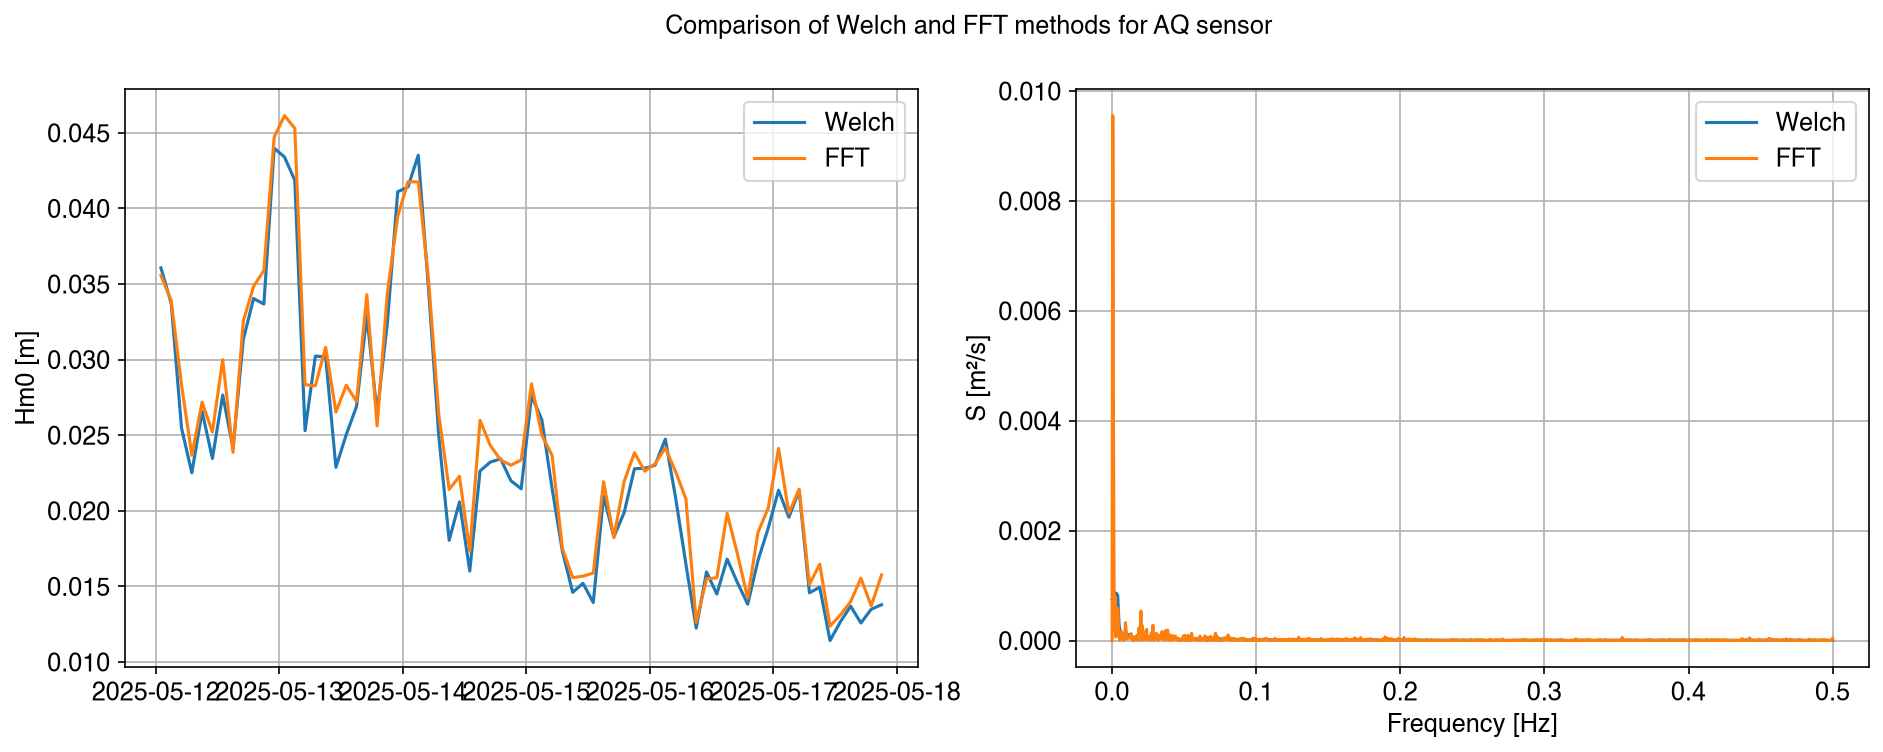

In [42]:
fig, ax = plt.subplots(1,2,figsize=(15,5),sharex=False)
ax[0].plot(dict_integral_params_welch['AQ'].index,dict_integral_params_welch['AQ']['Hm0'],label='Welch')
ax[0].plot(dict_integral_params_fft['AQ'].index,dict_integral_params_fft['AQ']['Hm0'],label='FFT')
ax[0].set_ylabel('Hm0 [m]')
ax[0].grid()
ax[0].legend()

ax[1].plot(dict_spectra_welch['AQ']['freq'],dict_spectra_welch['AQ']['S'][-1],label='Welch')
ax[1].plot(dict_spectra_fft['AQ']['freq'],dict_spectra_fft['AQ']['S'][-1],label='FFT')
ax[1].set_ylabel('S [m²/s]'); ax[1].set_xlabel('Frequency [Hz]')
ax[1].grid()
ax[1].legend()
fig.suptitle('Comparison of Welch and FFT methods for AQ sensor')


## GIS

### Import libraries

In [2]:
import pandas as pd
import geopandas as gpd

from oceanicospy.gis import (
    XYZFormatSpec,
    PointFileIO,
    PointFileReprojector,
    reproject_points,
    XYZMerger,
    AxisAlignedRectangle,
    XYZRectangleMask,
    ProfileAxis,
    ProfileInterpolator,
    Grid
)

### Read and reproject from xyz file

In [55]:
xyz_input_path = "../data/oceanicospy-example/gis/bathymetries/raw/SAI_50m/bat_sai_50m.txt"
xyz_output_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_9377_from_xyz.xyz"

reproject_points(
    input_path=xyz_input_path,
    output_path=xyz_output_path,
    target_epsg=9377,
    source_epsg=4326,
)

### Read and reproject from shp files

In [47]:
shp_path = "../data/oceanicospy-example/gis/bathymetries/raw/SAI_200m/bat_sai_200m.shp"
preview = PointFileIO(shp_path)
df_preview = preview.read()
print(df_preview.columns.tolist())
print(preview.read_as_geodataframe().crs)

['X', 'Field2', 'Y', 'Field4', 'Z', 'x', 'y']
EPSG:4326


In [48]:
vector_reprojected_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_200m_9377_from_shp.xyz"

reproject_points(
    input_path=shp_path,
    output_path=vector_reprojected_path,
    target_epsg=9377,
    z_column="Z",
)

### Merging files

In [3]:
tiles_dir = "../data/oceanicospy-example/gis/bathymetries/processed/"
merged_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_200m_9377_merged.xyz"

priority = [
    "MDE_SAI_2m_2020_ColenMapas_EPSG9377.xyz",  # highest priority
    "bat_sai_50m_9377_from_xyz.xyz",   
    "bat_sai_200m_9377_from_shp.xyz",  # lowest priority
]

merger = XYZMerger(
    input_dir=tiles_dir,
    priority=priority,
    crs=9377,
)

In [4]:
df_merged = merger.run_merge(merged_path)
df_merged.head()

,x,y,z
0,4070045.441,2940105.090,1909.419
1,4069847.849,2940111.440,1926.113
2,4069650.255,2940117.792,1932.791
3,4069452.661,2940124.146,1897.840
4,4069255.066,2940130.501,1915.992


In [ ]:
plt.tricontourf(df_merged['x'], df_merged['y'], df_merged['z'], levels=20, cmap='Blues_r')

## Models

### SWAN 2D

#### Import libraries

In [1]:
from oceanicospy.models.swanpy import Initializer
from oceanicospy.models.swanpy.preprocess import *
from oceanicospy.models.swanpy.execution import CaseRunner
from oceanicospy.models.swanpy.postprocess import SwanOutputReader
from oceanicospy.plots import *

#### Case configuration

In [3]:
domains = {
    1: {
        "grid": dict(lon_ll_corner=278.2, lat_ll_corner=12.4, x_extent=0.2, y_extent=0.3, nx=222, ny=333),
        "bathy": dict(lon_ll_corner_bot=278.1811, lat_ll_corner_bot=12.372, nx_bot=322, ny_bot=422, dx_bot=0.0009, dy_bot=0.0009),
        "fric": dict(lon_ll_corner_fric=278.1811, lat_ll_corner_fric=12.372, nx_fric=322, ny_fric=422, dx_fric=0.0009, dy_fric=0.0009),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.1811, lat_ll_corner_wl=12.372, nx_wl=322, ny_wl=422, dx_wl=0.0009, dy_wl=0.0009),
        "parent": None
    },
    2: {
        "grid": dict(lon_ll_corner=278.2265167, lat_ll_corner=12.4413166, x_extent=0.13185, y_extent=0.1908, nx=293, ny=424),
        "bathy": dict(lon_ll_corner_bot=278.2265167, lat_ll_corner_bot=12.4413166, nx_bot=293, ny_bot=424, dx_bot=0.00045, dy_bot=0.00045),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.2265167, lat_ll_corner_wl=12.4413166, nx_wl=293, ny_wl=424, dx_wl=0.00045, dy_wl=0.00045),
        "fric": dict(lon_ll_corner_fric=278.2265167, lat_ll_corner_fric=12.4413166, nx_fric=293, ny_fric=424, dx_fric=0.00045, dy_fric=0.00045),
        "parent": 1
    },
    3: {
        "grid": dict(lon_ll_corner=278.270165, lat_ll_corner=12.550217, x_extent=0.0747, y_extent=0.0747, nx=332, ny=332),
        "bathy": dict(lon_ll_corner_bot=278.270165, lat_ll_corner_bot=12.550217, nx_bot=332, ny_bot=332, dx_bot=0.000225, dy_bot=0.000225),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.270165, lat_ll_corner_wl=12.550217, nx_wl=332, ny_wl=332, dx_wl=0.000225, dy_wl=0.000225),
        "fric": dict(lon_ll_corner_fric=278.270165, lat_ll_corner_fric=12.550217, nx_fric=332, ny_fric=332, dx_fric=0.000225, dy_fric=0.000225),
        "parent": 2
    }}

In [7]:
path_case = '../data/oceanicospy-example/model_runs/nonstationary_swan/'

ini_date = datetime(2025, 5, 10, 0)
end_date = datetime(2025, 5, 17, 23)

dict_ini_data = dict(
    name             = 'Non-stationary',
    case_number      = 1,
    case_description = 'Example non-stationary case for San Andres',
    stat_id          = 0, # 0 → non-stationary
    number_domains   = len(domains),
    parent_domains   = {d:cfg["parent"] for d, cfg in domains.items()})

#### Initializer

In [4]:
case = Initializer(
    root_path     = path_case,
    dict_ini_data = dict_ini_data,
    ini_date      = ini_date,
    end_date      = end_date,
)

case.create_folders()       # creates all project folders
case.replace_ini_data()     # writes run.swn from the NONSTAT template

*** Initializing SWAN model ***


	*** Creating project folder structure ***


	*** Copying base SWAN configuration file into run folder ***



#### Configure grid

In [5]:
for domain_id,config in domains.items():
    domain_grid_dict = config["grid"]
    case_grid = GridMaker(init = case,
                          domain_number = domain_id, 
                          grid_info = domain_grid_dict)
    case_grid.fill_grid_section()


*** Initializing gridmaker for domain 1 ***


 	*** Adding/Editing grid information for domain 1 in configuration file ***


*** Initializing gridmaker for domain 2 ***


 	*** Adding/Editing grid information for domain 2 in configuration file ***


*** Initializing gridmaker for domain 3 ***


 	*** Adding/Editing grid information for domain 3 in configuration file ***



#### Configure bathymetry

In [21]:
# Create a regular target grid
merged_path='../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_200m_9377_merged.xyz'
reader_geo = PointFileIO(merged_path, crs=9377)
gdf = reader_geo.read_as_geodataframe()
gdf = gdf.to_crs(epsg=4326)  # Reproject to WGS84 for consistency
gdf = gdf[gdf != -9999]  # Filter out invalid depth values

In [5]:
from scipy.interpolate import griddata

In [22]:
for d in list(domains.keys()):
    d_info=domains[d]['bathy']
    grid_x, grid_y = np.meshgrid(np.linspace(d_info['lon_ll_corner_bot'], d_info['lon_ll_corner_bot']+d_info['nx_bot']*d_info['dx_bot'], d_info['nx_bot']),
                                  np.linspace(d_info['lat_ll_corner_bot'], d_info['lat_ll_corner_bot']+d_info['ny_bot']*d_info['dy_bot'], d_info['ny_bot']))

    # Run the interpolation
    grid_z = griddata((gdf['geometry'].x.values+360, gdf['geometry'].y.values), gdf['z'].values, (grid_x, grid_y), method='nearest')
    np.savetxt(f'{path_case}input/domain_0{d}/bot{d}.bot', grid_z, delimiter=' ', fmt='%.4f')

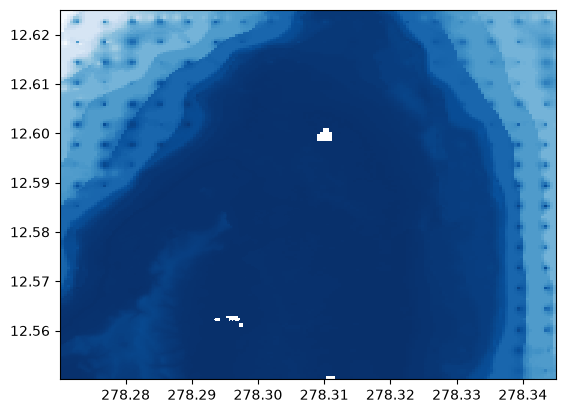

In [23]:
plt.pcolormesh(grid_x, grid_y, grid_z, shading='auto', cmap='Blues_r')

In [24]:
for domain_id,config in domains.items():
    domain_bathy_dict = config["bathy"]
    case_bathy = BathyMaker(init = case,
                          domain_number = domain_id, 
                          bathy_info = domain_bathy_dict)
    case_bathy.use_ascii_file_from_user()
    case_bathy.fill_bathy_section()


*** Initializing bathymaker for domain 1 ***


 	*** Adding/Editing bathymetry information for domain 1 in configuration file ***


*** Initializing bathymaker for domain 2 ***


 	*** Adding/Editing bathymetry information for domain 2 in configuration file ***


*** Initializing bathymaker for domain 3 ***


 	*** Adding/Editing bathymetry information for domain 3 in configuration file ***



present swan 2D nonstationary case

### XBeach 1D

present xbeach 1D case

**compare results xbeach vs AQ and RBR outputs